In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os


In [2]:
current_dir = os.getcwd()
df = pd.read_csv(f'{current_dir}\\retail_store_inventory.csv')
df_copy = df.copy()


In [3]:
df_copy.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

In [4]:
df_copy[['Units Sold', 'Units Ordered']] = df_copy[['Units Sold', 'Units Ordered']].astype(float)

In [5]:
df_copy.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [6]:
df_copy.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


Calculated the Sales per day

In [7]:
df_copy['Sales'] = df_copy['Units Sold'] * df_copy['Price']
df_copy['Sales']

0         4254.50
1         9451.50
2         1819.35
3         1995.92
4         1030.96
           ...   
73095      589.84
73096     4211.07
73097      399.96
73098    14028.96
73099      470.34
Name: Sales, Length: 73100, dtype: float64

Formatted the Dates

In [8]:
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
grouped_data = df_copy.groupby('Date')[['Units Sold', 'Price', 'Sales']].sum().reset_index()
grouped_data

,Date,Units Sold,Price,Sales
0,2022-01-01,14484.0,5751.57,879026.03
1,2022-01-02,13415.0,6063.65,836077.35
2,2022-01-03,13681.0,5679.93,731941.24
3,2022-01-04,14084.0,5299.30,719558.41
4,2022-01-05,12572.0,5599.58,712140.43
...,...,...,...,...
726,2023-12-28,16271.0,5830.97,970320.86
727,2023-12-29,13368.0,5623.86,731055.43
728,2023-12-30,13156.0,6072.18,824077.83
729,2023-12-31,11208.0,5925.18,649300.54


Calculated the Moving Averages to a Second DF

In [9]:
grouped_data['MovingAve7'] = grouped_data['Sales'].rolling(window=7).mean()

#calculate the 30-day moving average
grouped_data['MovingAve30'] = grouped_data['Sales'].rolling(window=30).mean()


Exporting the Dataframes to CSV

In [10]:
df_copy.to_csv(f'{current_dir}\\cleaned_retail_store_inventory.csv', index=False)
grouped_data.to_csv(f'{current_dir}\\grouped_data_sales.csv', index=False)

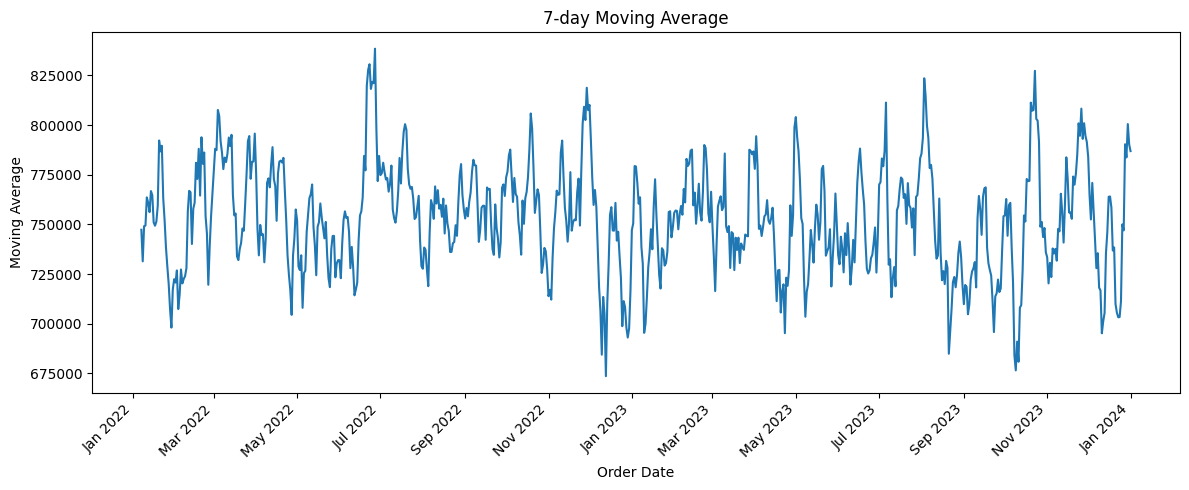

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_data['Date'], grouped_data['MovingAve7'])
plt.xlabel('Order Date')
plt.ylabel('Moving Average')
plt.title('7-day Moving Average')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


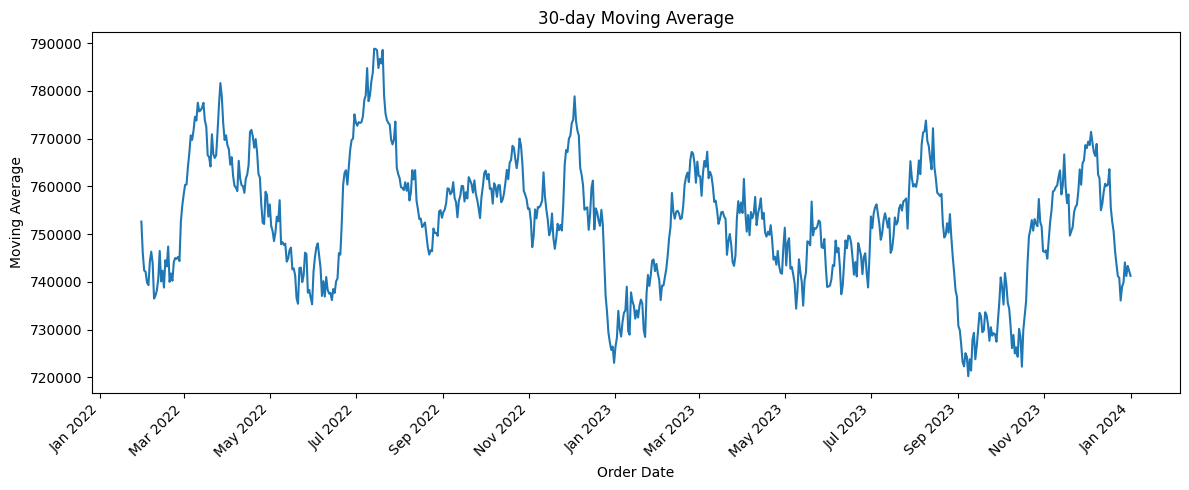

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_data['Date'], grouped_data['MovingAve30'])
plt.xlabel('Order Date')
plt.ylabel('Moving Average')
plt.title('30-day Moving Average')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()